In [7]:
##### Creates scatterplot of pixel share of country capital/labor vs share of country production (tonnes)

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import rasterio
from scipy import stats

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital_labor = pd.read_parquet(f"{cd}/Results/Raster_model/intermediate_outputs/capital_labor_predictions_rescaled.parquet")

country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# Production data (raster)
production_path = f'{cd}/Data/Clean/Production/total_production_tonnes_2020.tif'

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/plot_vs_share_production"

In [3]:
##### Calculate pixel shares 

# get production totals by country 
production_totals = capital_labor[['ISO3', 'total_production_tonnes_2020']].groupby('ISO3').sum().reset_index()
production_totals = production_totals.rename(columns={'total_production_tonnes_2020': 'national_total_production_tonnes_2020'})
capital_labor = capital_labor.merge(production_totals, on='ISO3', how='left')

# calculate shares
capital_labor['share_national_production'] = capital_labor['total_production_tonnes_2020'] / capital_labor['national_total_production_tonnes_2020']
capital_labor['share_national_capital'] = capital_labor['rescaled_capital_USD'] / capital_labor['national_total_capital_USD']
capital_labor['share_national_labor'] = capital_labor['rescaled_jobs'] / capital_labor['national_total_jobs']

In [5]:
##### Save pixel shares as rasters

# define function to convert to raster 
def save_column_as_raster(df, value_col, reference_raster_path, output_path):

    # use production raster as reference grid
    with rasterio.open(reference_raster_path) as ref:
        transform = ref.transform
        crs = ref.crs
        height = ref.height
        width = ref.width

    # pivot into 2D grid: rows = y, cols = x
    pivot = df.pivot(index='y', columns='x', values=value_col)

    # match raster row/col order: y descending (north to south), x ascending
    pivot = pivot.sort_index(ascending=False)
    pivot = pivot.reindex(columns=sorted(pivot.columns))

    arr = pivot.values.astype(np.float32)

    if arr.shape != (height, width):
        raise ValueError(
            f"Shape mismatch for {value_col}: got {arr.shape}, expected {(height, width)}"
        )

    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=np.nan
    ) as dst:
        dst.write(arr, 1)

# save 
output_cols = [
    'share_national_production',
    'share_national_capital',
    'share_national_labor'
]

for col in output_cols:
    out_path = f"{fd}/{col}.tif" 
    save_column_as_raster(capital_labor, col, production_path, out_path)
    print(f"Saved {col} -> {out_path}")

Saved share_national_production -> /Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/plot_vs_share_production/share_national_production.tif
Saved share_national_capital -> /Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/plot_vs_share_production/share_national_capital.tif
Saved share_national_labor -> /Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/plot_vs_share_production/share_national_labor.tif


/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_19204/2334715295.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_19204/2334715295.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{fd}/scatterplot_capital.png", dpi=300, bbox_inches='tight')
/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


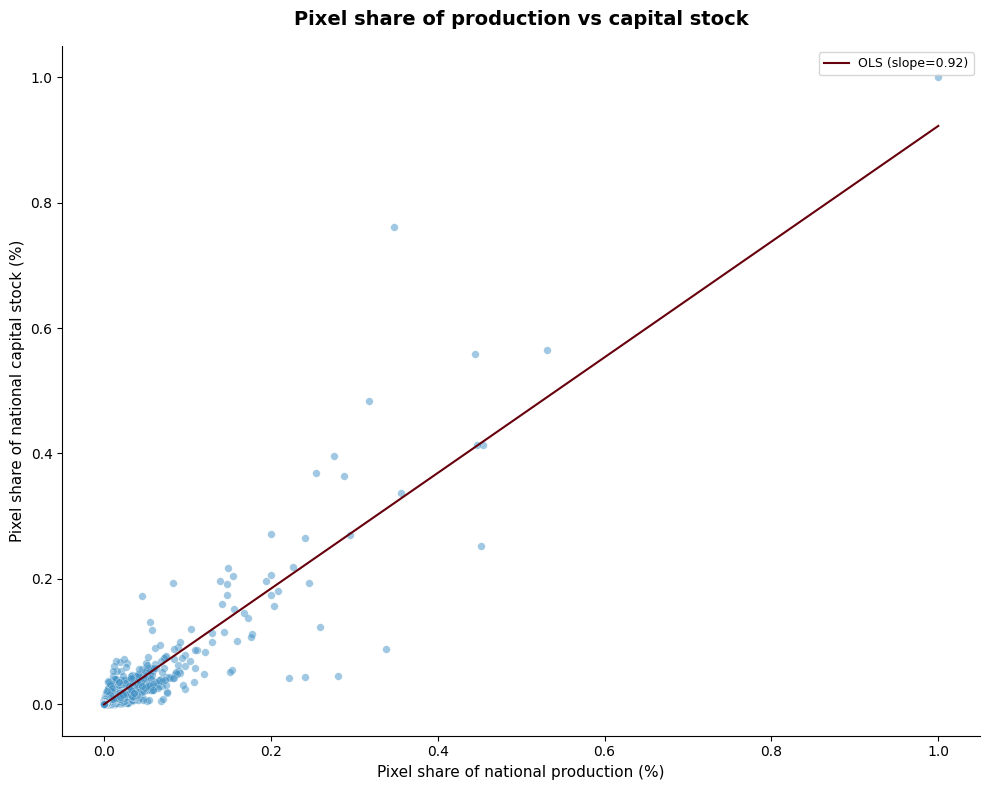

In [8]:
##### Scatterplot of pixel share of national total: capital vs production

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter
ax.scatter(
    capital_labor['share_national_production'],
    capital_labor['share_national_capital'],
    color='#4292c6',
    alpha=0.5,
    edgecolors='white',
    linewidths=0.3,
    s=30,
    zorder=2
)

# OLS trend line
mask = capital_labor[['share_national_production', 'share_national_capital']].notna().all(axis=1)
x = capital_labor.loc[mask, 'share_national_production']
y = capital_labor.loc[mask, 'share_national_capital']

slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='#67000d', linewidth=1.5, zorder=3, label=f'OLS (slope={slope:.2f})')

# Aesthetics
ax.set_xlabel("Pixel share of national production (%)", fontsize=11)
ax.set_ylabel("Pixel share of national capital stock (%)", fontsize=11)
ax.set_title("Pixel share of production vs capital stock", fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f"{fd}/scatterplot_capital.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
### Data prep for maps

# set file_paths
production_share = rio.open_rasterio(f"{fd}/share_national_production.tif")
capital_share = rio.open_rasterio(f"{fd}/share_national_capital.tif")
labor_share = rio.open_rasterio(f"{fd}/share_national_labor.tif")

# align crs
crs = "ESRI:54042"

production_share = production_share.rio.reproject(crs)
capital_share = capital_share.rio.reproject(crs)
labor_share = labor_share.rio.reproject(crs)

country_boundaries = country_boundaries.to_crs(crs)

In [ ]:
##### Produce map of pixel share of national total 

# Prepare rasters
production_share_plot = production_share.squeeze()
capital_share_plot = capital_share.squeeze()
labor_share_plot = labor_share.squeeze()

# Create figure with two panels sharing axes
fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharex=True, sharey=True)

panels = [
    (axes[0], production_share_plot, "Production"),
    (axes[1], capital_share_plot, "Capital Stock"),
    (axes[2], labor_share_plot, "Labor")
]

for ax, data, subtitle in panels:
    # Country borders underneath
    country_boundaries.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.6,
        zorder=1
    )

    # Raster on top
    im = data.plot(
        ax=ax,
        cmap="turbo",
        vmin=0.1,
        vmax=100,
        add_colorbar=False,
        add_labels=False,
        zorder=2
    )

    ax.set_axis_off()
    ax.set_title(subtitle, fontsize=14, weight='bold', pad=15)

fig.suptitle("Pixel Share of National Total", fontsize=18, weight='bold', y=0.98)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.02,
    pad=0.02,
    shrink=0.6
)
cbar.set_label("%", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.savefig(f"{fd}/map_share_national_total.png", dpi=300, bbox_inches='tight')
plt.show()